## Модели прогнозирования объема надоя молока по Акмолинской области

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pylab import rcParams
from IPython.display import display
import math
from prophet import Prophet
pd.set_option('display.max_columns', 130)


import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

### Подготовка данных и EDA

In [2]:
df = pd.read_excel("Датасет по молоку с регрессорами.xlsx")
df.sample(10)

,Регион,Период,Молоко,Осадки,Поголовье: КРС,Температура,Цена: Молоко
1980,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2019-02,44335.4,22.1,1036129.0,2.314286,109.170516
1850,ПАВЛОДАРСКАЯ ОБЛАСТЬ,2024-11,16120.0,25.7,467204.0,-4.350000,242.234827
1065,ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2017-03,9455.8,21.2,550739.0,-2.719355,120.774136
52,АКМОЛИНСКАЯ ОБЛАСТЬ,2019-05,43376.9,24.9,510989.0,13.312903,134.796541
1290,КОСТАНАЙСКАЯ ОБЛАСТЬ,2015-12,17398.7,58.7,422367.0,-6.870968,86.371645
787,ГАСТАНА,2020-08,27.2,38.8,323.0,19.948387,NaN
1357,КОСТАНАЙСКАЯ ОБЛАСТЬ,2021-07,52119.1,103.5,532491.0,21.358065,150.638584
337,АЛМАТИНСКАЯ ОБЛАСТЬ,2023-02,15095.6,20.0,52164.0,-2.067857,208.641319
1015,ЖАМБЫЛСКАЯ ОБЛАСТЬ,2023-01,11573.1,26.9,30386.0,-8.522581,170.758682
1727,ОБЛАСТЬ ҰЛЫТАУ,2024-08,7304.7,7.2,165272.0,22.406452,101.841818


In [3]:
df_akmola = df[df['Регион'] == 'АКМОЛИНСКАЯ ОБЛАСТЬ']
df_akmola = df_akmola.drop('Регион', axis = 'columns')
df_akmola.head()

,Период,Молоко,Осадки,Поголовье: КРС,Температура,Цена: Молоко
0,2015-01,12800.2,9.8,372560.0,-12.490323,100.700000
1,2015-02,15349.3,9.8,399442.0,-10.192857,100.700000
2,2015-03,25086.1,8.3,425605.0,-5.870968,100.297200
3,2015-04,31661.4,8.8,440023.0,4.490000,100.196903
4,2015-05,49129.8,42.8,444647.0,14.574194,96.289224


In [4]:
df_akmola['Период'] = pd.to_datetime(df_akmola['Период'], format='%Y-%m')
df_akmola.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Период          120 non-null    datetime64[ns]
 1   Молоко          120 non-null    float64       
 2   Осадки          120 non-null    float64       
 3   Поголовье: КРС  120 non-null    float64       
 4   Температура     120 non-null    float64       
 5   Цена: Молоко    120 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 6.6 KB


In [5]:
df_akmola.isna().sum()

Период            0
Молоко            0
Осадки            0
Поголовье: КРС    0
Температура       0
Цена: Молоко      0
dtype: int64

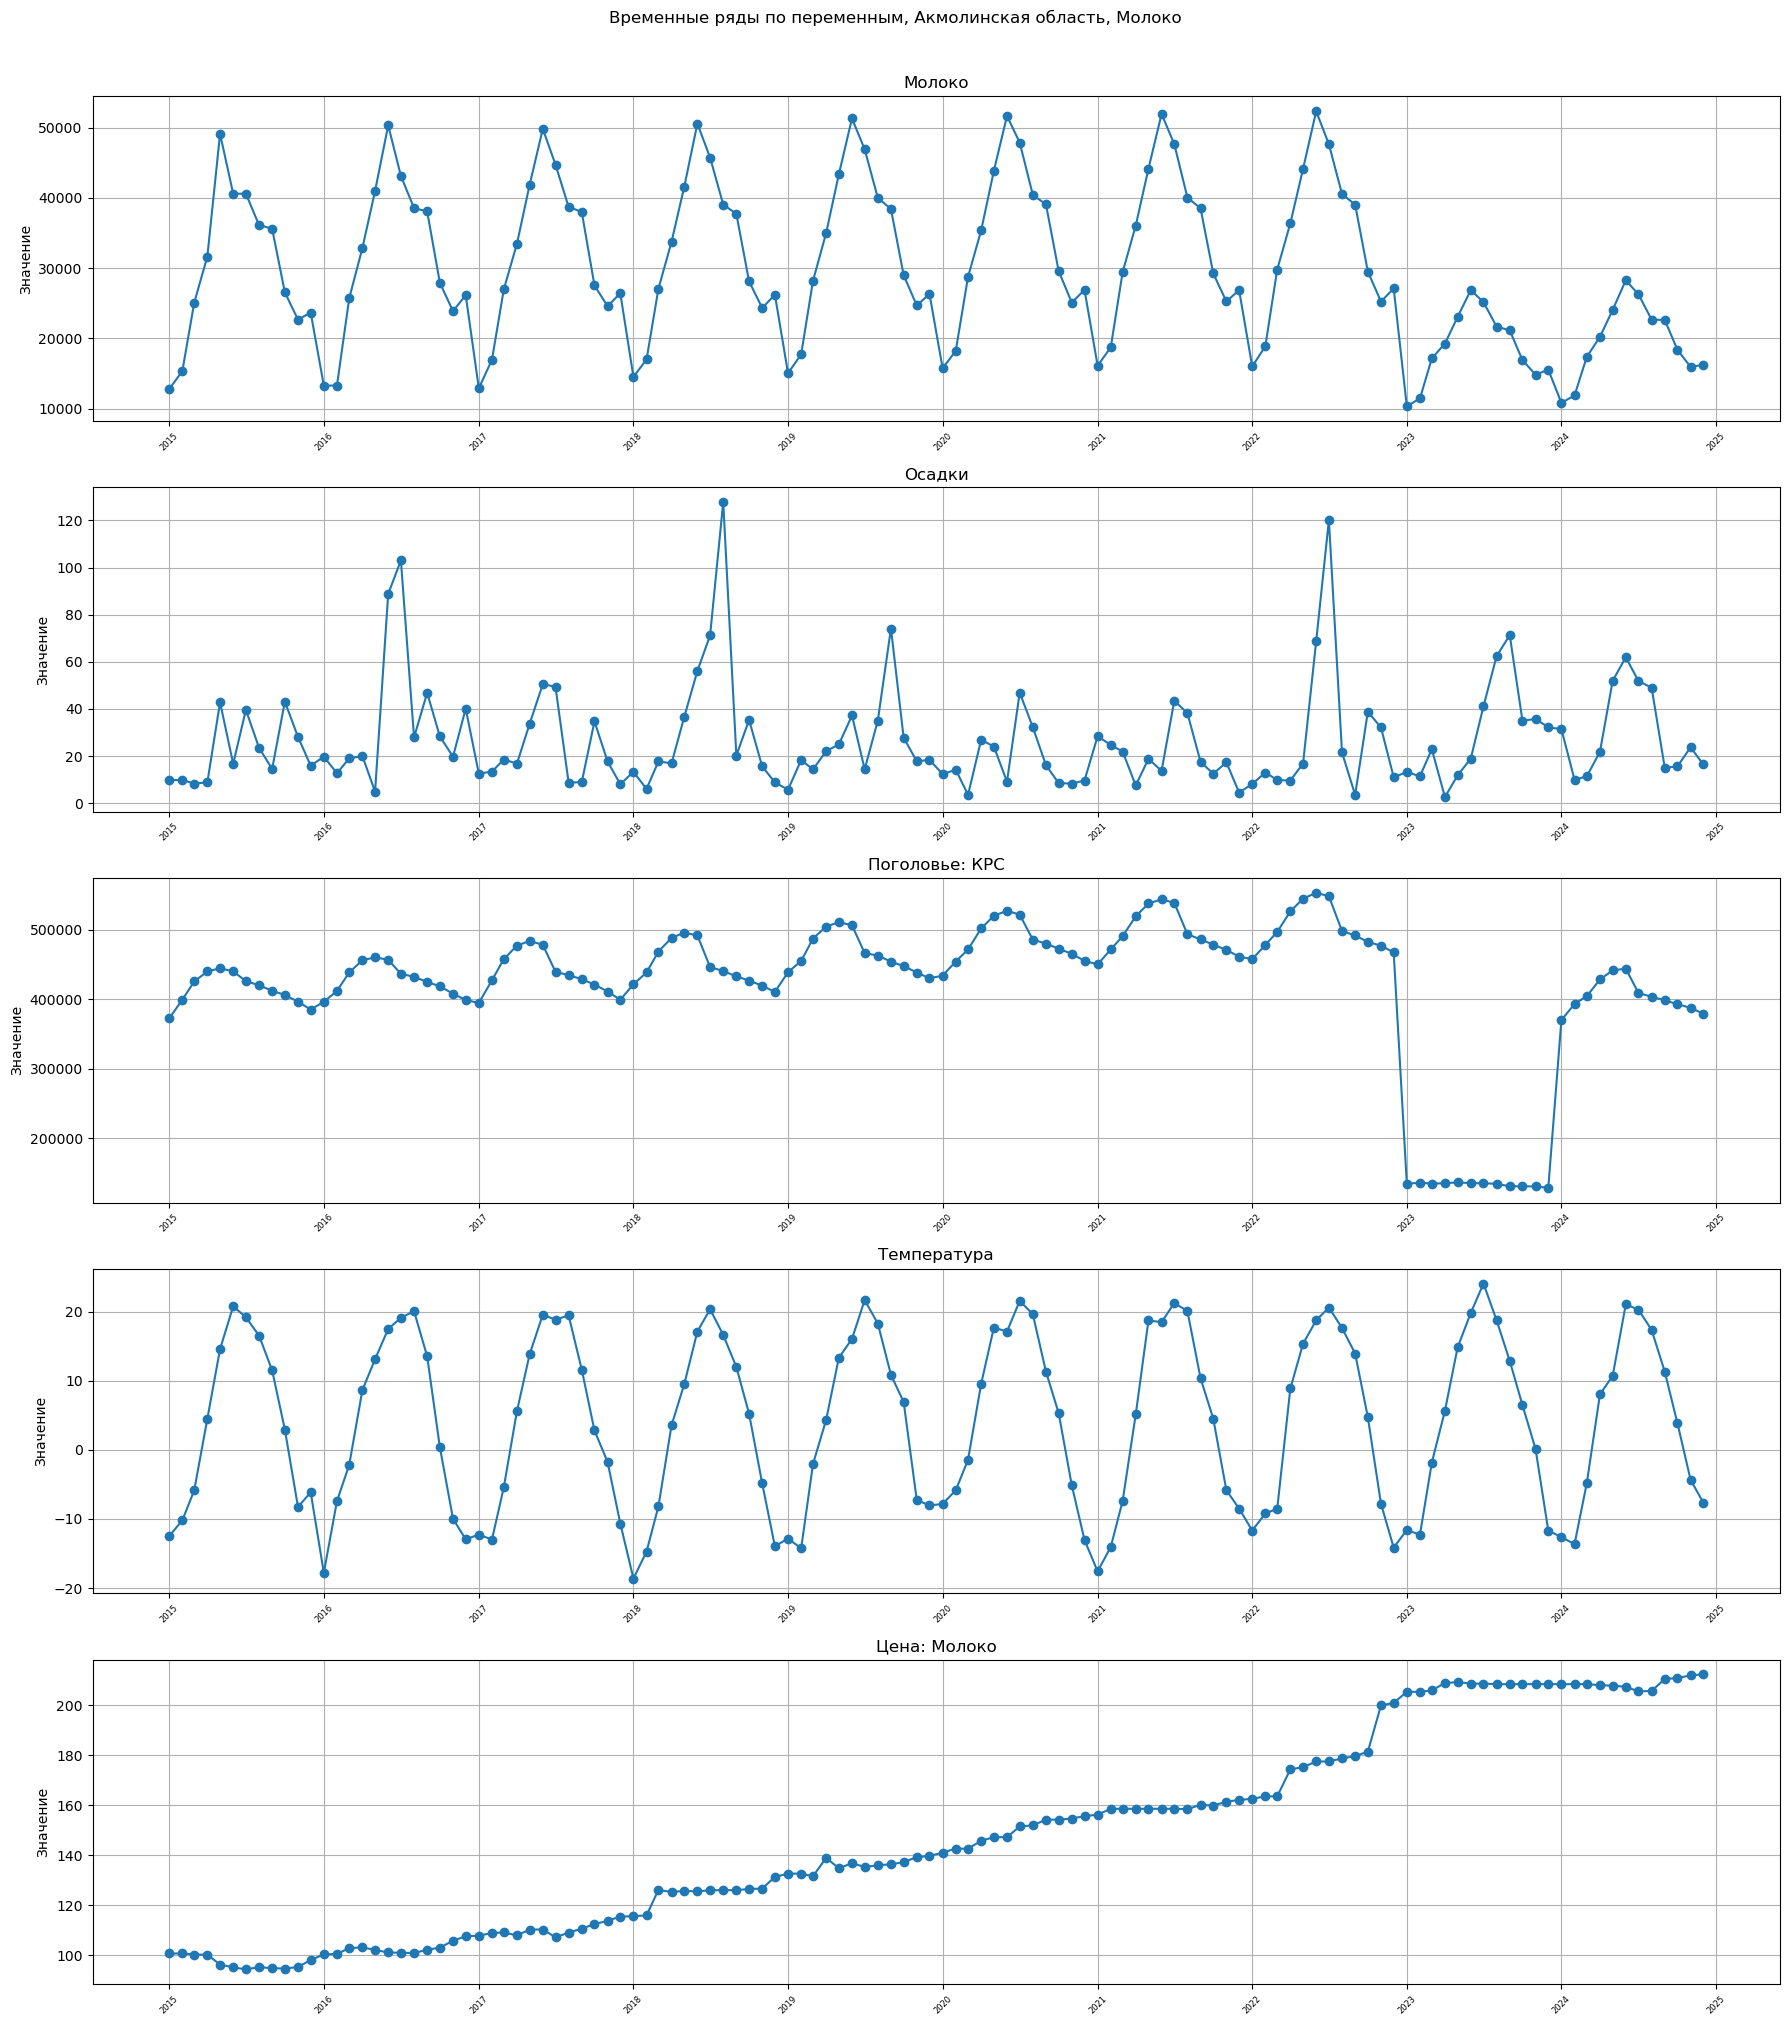

In [6]:
# Plot each variable in its own subplot
value_cols = [col for col in df_akmola.columns if col not in ["Период"]]

n = len(value_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(value_cols, 1):
    plt.subplot(n, 1, i)
    plt.plot(df_akmola["Период"], df_akmola[col], marker="o")
    plt.title(f"{col}")
    plt.grid(True)
    plt.ylabel("Значение")
    plt.xticks(rotation=45, fontsize = 6)

plt.suptitle("Временные ряды по переменным, Акмолинская область, Молоко", y=1.01)
plt.tight_layout()
plt.show()

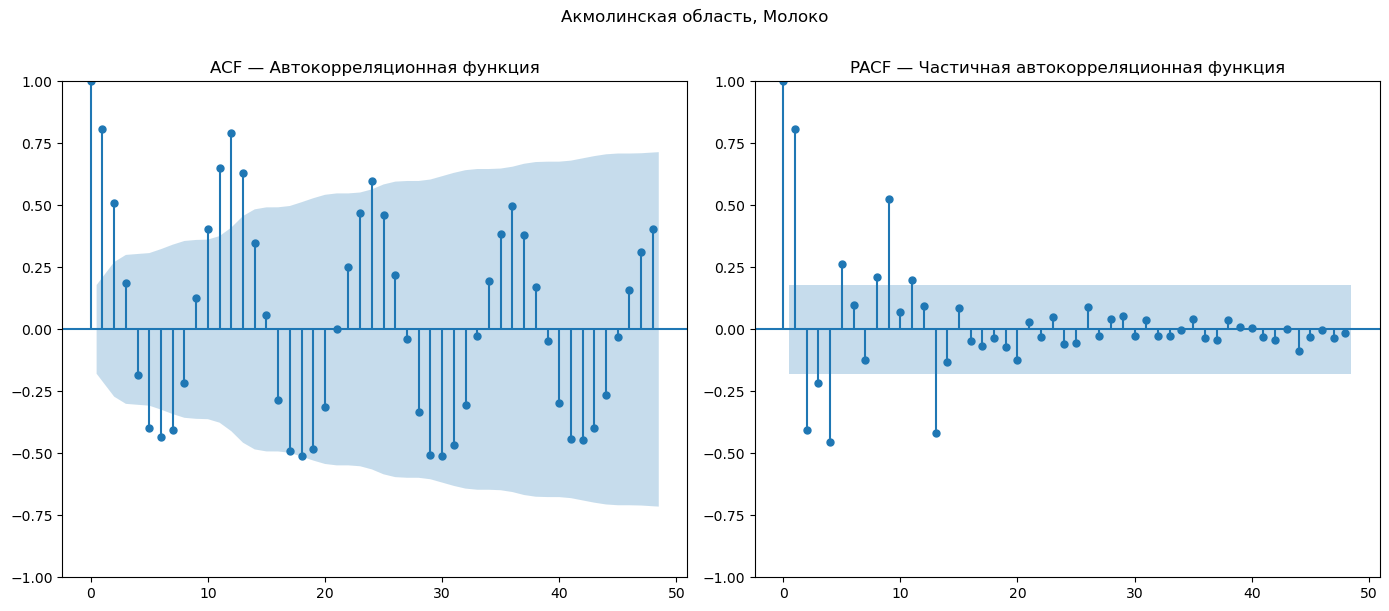

In [7]:
y = df_akmola["Молоко"].sort_index()

# Plot ACF and PACF
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_acf(y, lags=48, ax=plt.gca(), title="ACF — Автокорреляционная функция")

plt.subplot(1, 2, 2)
plot_pacf(y, lags=48, ax=plt.gca(), title="PACF — Частичная автокорреляционная функция", method="ywm")
plt.suptitle("Акмолинская область, Молоко", y=1.01)

plt.tight_layout()
plt.show()

Графики автокорреляционной и частичной автокорреляционной функций указывают на **сильную взаимосвязь показателей текущего месяца со значениями следующих 2 месяцев** и на возможную **годовую сезонность** (пик на +12 месяцев). 

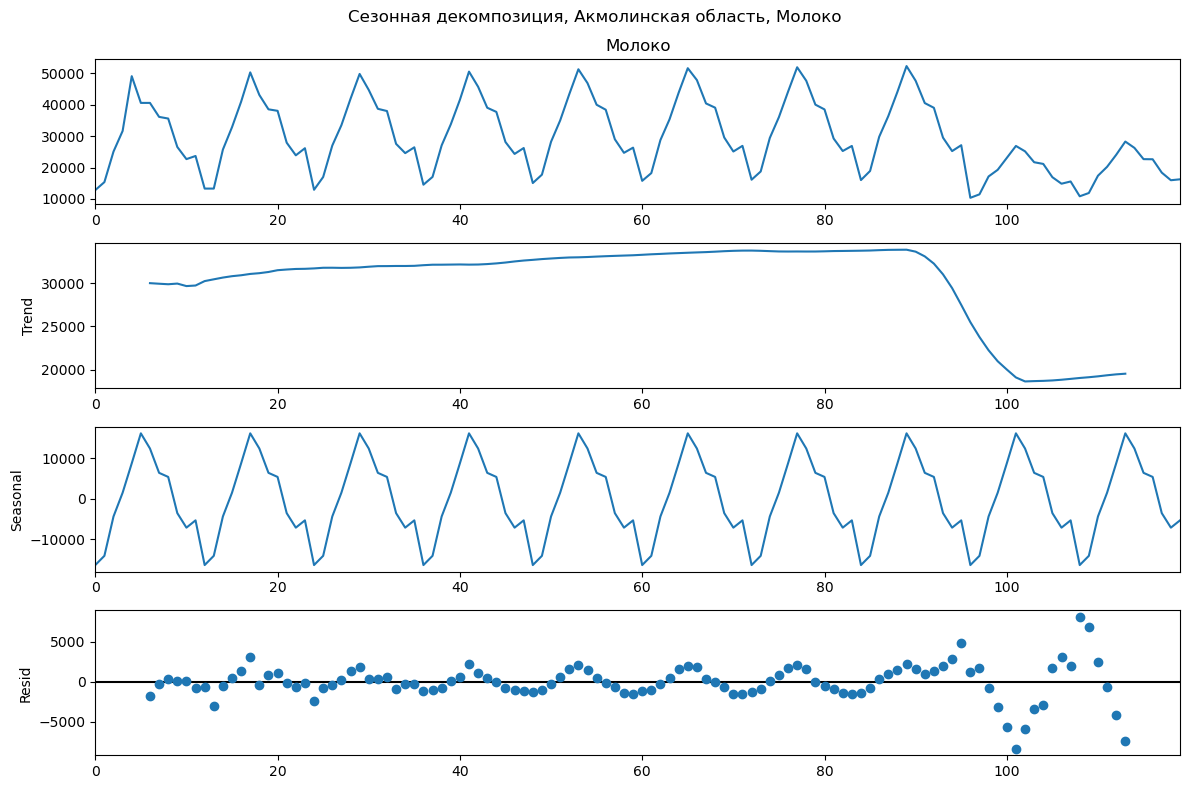

In [8]:
# Perform decomposition (period=12 for monthly data)
decomposition = seasonal_decompose(df_akmola["Молоко"], model="additive", period=12)

# Plot with larger figure size
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Сезонная декомпозиция, Акмолинская область, Молоко", fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
# Run ADF test
result = adfuller(df_akmola["Молоко"])

# Display results
print("📊 Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

# Interpretation
if result[1] < 0.05:
    print("✅ The series is likely **stationary** (reject H₀).")
else:
    print("❌ The series is likely **non-stationary** (fail to reject H₀).")


📊 Augmented Dickey-Fuller Test Results:
ADF Statistic: -2.3752
p-value: 0.1489
Critical Value (1%): -3.4936
Critical Value (5%): -2.8892
Critical Value (10%): -2.5815
❌ The series is likely **non-stationary** (fail to reject H₀).


Результаты теста ADF указывают на **нестационарность** временного ряда.

In [10]:
df_akmola

,Период,Молоко,Осадки,Поголовье: КРС,Температура,Цена: Молоко
0,2015-01-01,12800.2,9.8,372560.0,-12.490323,100.700000
1,2015-02-01,15349.3,9.8,399442.0,-10.192857,100.700000
2,2015-03-01,25086.1,8.3,425605.0,-5.870968,100.297200
3,2015-04-01,31661.4,8.8,440023.0,4.490000,100.196903
4,2015-05-01,49129.8,42.8,444647.0,14.574194,96.289224
...,...,...,...,...,...,...
115,2024-08-01,22673.0,49.0,403674.0,17.338710,205.754700
116,2024-09-01,22635.3,15.0,398450.0,11.300000,210.487058
117,2024-10-01,18373.4,15.6,392916.0,3.832258,210.908032
118,2024-11-01,15949.9,23.7,387565.0,-4.343333,211.962572


In [11]:
# Создание лагов t-1 до t-6 для переменных
for lag in range(1, 7):
    df_akmola[f"Молоко_t-{lag}"] = df_akmola["Молоко"].shift(lag)
    df_akmola[f"Температура_t-{lag}"] = df_akmola["Температура"].shift(lag)
    df_akmola[f"Осадки_t-{lag}"] = df_akmola["Осадки"].shift(lag)
    df_akmola[f"Поголовье: КРС_t-{lag}"] = df_akmola["Поголовье: КРС"].shift(lag)
    df_akmola[f"Цена: Молоко_t-{lag}"] = df_akmola["Цена: Молоко"].shift(lag)

df_akmola_full = df_akmola[["Период", "Молоко", 
                            "Молоко_t-1", "Молоко_t-2", "Молоко_t-3", "Молоко_t-4", "Молоко_t-5", "Молоко_t-6",
                            "Температура", "Температура_t-1", "Температура_t-2", "Температура_t-3", "Температура_t-4", "Температура_t-5", "Температура_t-6",
                            "Осадки", "Осадки_t-1", "Осадки_t-2", "Осадки_t-3", "Осадки_t-4", "Осадки_t-5", "Осадки_t-6",
                            "Поголовье: КРС", "Поголовье: КРС_t-1", "Поголовье: КРС_t-2", "Поголовье: КРС_t-3", "Поголовье: КРС_t-4", "Поголовье: КРС_t-5", "Поголовье: КРС_t-6",
                            "Цена: Молоко", "Цена: Молоко_t-1", "Цена: Молоко_t-2", "Цена: Молоко_t-3", "Цена: Молоко_t-4", "Цена: Молоко_t-5", "Цена: Молоко_t-6"]]
df_akmola_full

,Период,Молоко,Молоко_t-1,Молоко_t-2,Молоко_t-3,Молоко_t-4,Молоко_t-5,Молоко_t-6,Температура,Температура_t-1,Температура_t-2,Температура_t-3,Температура_t-4,Температура_t-5,Температура_t-6,Осадки,Осадки_t-1,Осадки_t-2,Осадки_t-3,Осадки_t-4,Осадки_t-5,Осадки_t-6,Поголовье: КРС,Поголовье: КРС_t-1,Поголовье: КРС_t-2,Поголовье: КРС_t-3,Поголовье: КРС_t-4,Поголовье: КРС_t-5,Поголовье: КРС_t-6,Цена: Молоко,Цена: Молоко_t-1,Цена: Молоко_t-2,Цена: Молоко_t-3,Цена: Молоко_t-4,Цена: Молоко_t-5,Цена: Молоко_t-6
0,2015-01-01,12800.2,NaN,NaN,NaN,NaN,NaN,NaN,-12.490323,NaN,NaN,NaN,NaN,NaN,NaN,9.8,NaN,NaN,NaN,NaN,NaN,NaN,372560.0,NaN,NaN,NaN,NaN,NaN,NaN,100.700000,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-02-01,15349.3,12800.2,NaN,NaN,NaN,NaN,NaN,-10.192857,-12.490323,NaN,NaN,NaN,NaN,NaN,9.8,9.8,NaN,NaN,NaN,NaN,NaN,399442.0,372560.0,NaN,NaN,NaN,NaN,NaN,100.700000,100.700000,NaN,NaN,NaN,NaN,NaN
2,2015-03-01,25086.1,15349.3,12800.2,NaN,NaN,NaN,NaN,-5.870968,-10.192857,-12.490323,NaN,NaN,NaN,NaN,8.3,9.8,9.8,NaN,NaN,NaN,NaN,425605.0,399442.0,372560.0,NaN,NaN,NaN,NaN,100.297200,100.700000,100.700000,NaN,NaN,NaN,NaN
3,2015-04-01,31661.4,25086.1,15349.3,12800.2,NaN,NaN,NaN,4.490000,-5.870968,-10.192857,-12.490323,NaN,NaN,NaN,8.8,8.3,9.8,9.8,NaN,NaN,NaN,440023.0,425605.0,399442.0,372560.0,NaN,NaN,NaN,100.196903,100.297200,100.700000,100.700000,NaN,NaN,NaN
4,2015-05-01,49129.8,31661.4,25086.1,15349.3,12800.2,NaN,NaN,14.574194,4.490000,-5.870968,-10.192857,-12.490323,NaN,NaN,42.8,8.8,8.3,9.8,9.8,NaN,NaN,444647.0,440023.0,425605.0,399442.0,372560.0,NaN,NaN,96.289224,100.196903,100.297200,100.700000,100.700000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-08-01,22673.0,26267.7,28277.0,24058.8,20221.1,17387.5,11876.6,17.338710,20.270968,21.043333,10.696774,8.026667,-4.809677,-13.644828,49.0,51.8,61.9,51.9,21.8,11.4,9.9,403674.0,408936.0,444063.0,441647.0,428509.0,404506.0,393245.0,205.754700,205.549151,207.415894,207.831557,208.039597,208.456510,208.456510
116,2024-09-01,22635.3,22673.0,26267.7,28277.0,24058.8,20221.1,17387.5,11.300000,17.338710,20.270968,21.043333,10.696774,8.026667,-4.809677,15.0,49.0,51.8,61.9,51.9,21.8,11.4,398450.0,403674.0,408936.0,444063.0,441647.0,428509.0,404506.0,210.487058,205.754700,205.549151,207.415894,207.831557,208.039597,208.456510
117,2024-10-01,18373.4,22635.3,22673.0,26267.7,28277.0,24058.8,20221.1,3.832258,11.300000,17.338710,20.270968,21.043333,10.696774,8.026667,15.6,15.0,49.0,51.8,61.9,51.9,21.8,392916.0,398450.0,403674.0,408936.0,444063.0,441647.0,428509.0,210.908032,210.487058,205.754700,205.549151,207.415894,207.831557,208.039597
118,2024-11-01,15949.9,18373.4,22635.3,22673.0,26267.7,28277.0,24058.8,-4.343333,3.832258,11.300000,17.338710,20.270968,21.043333,10.696774,23.7,15.6,15.0,49.0,51.8,61.9,51.9,387565.0,392916.0,398450.0,403674.0,408936.0,444063.0,441647.0,211.962572,210.908032,210.487058,205.754700,205.549151,207.415894,207.831557


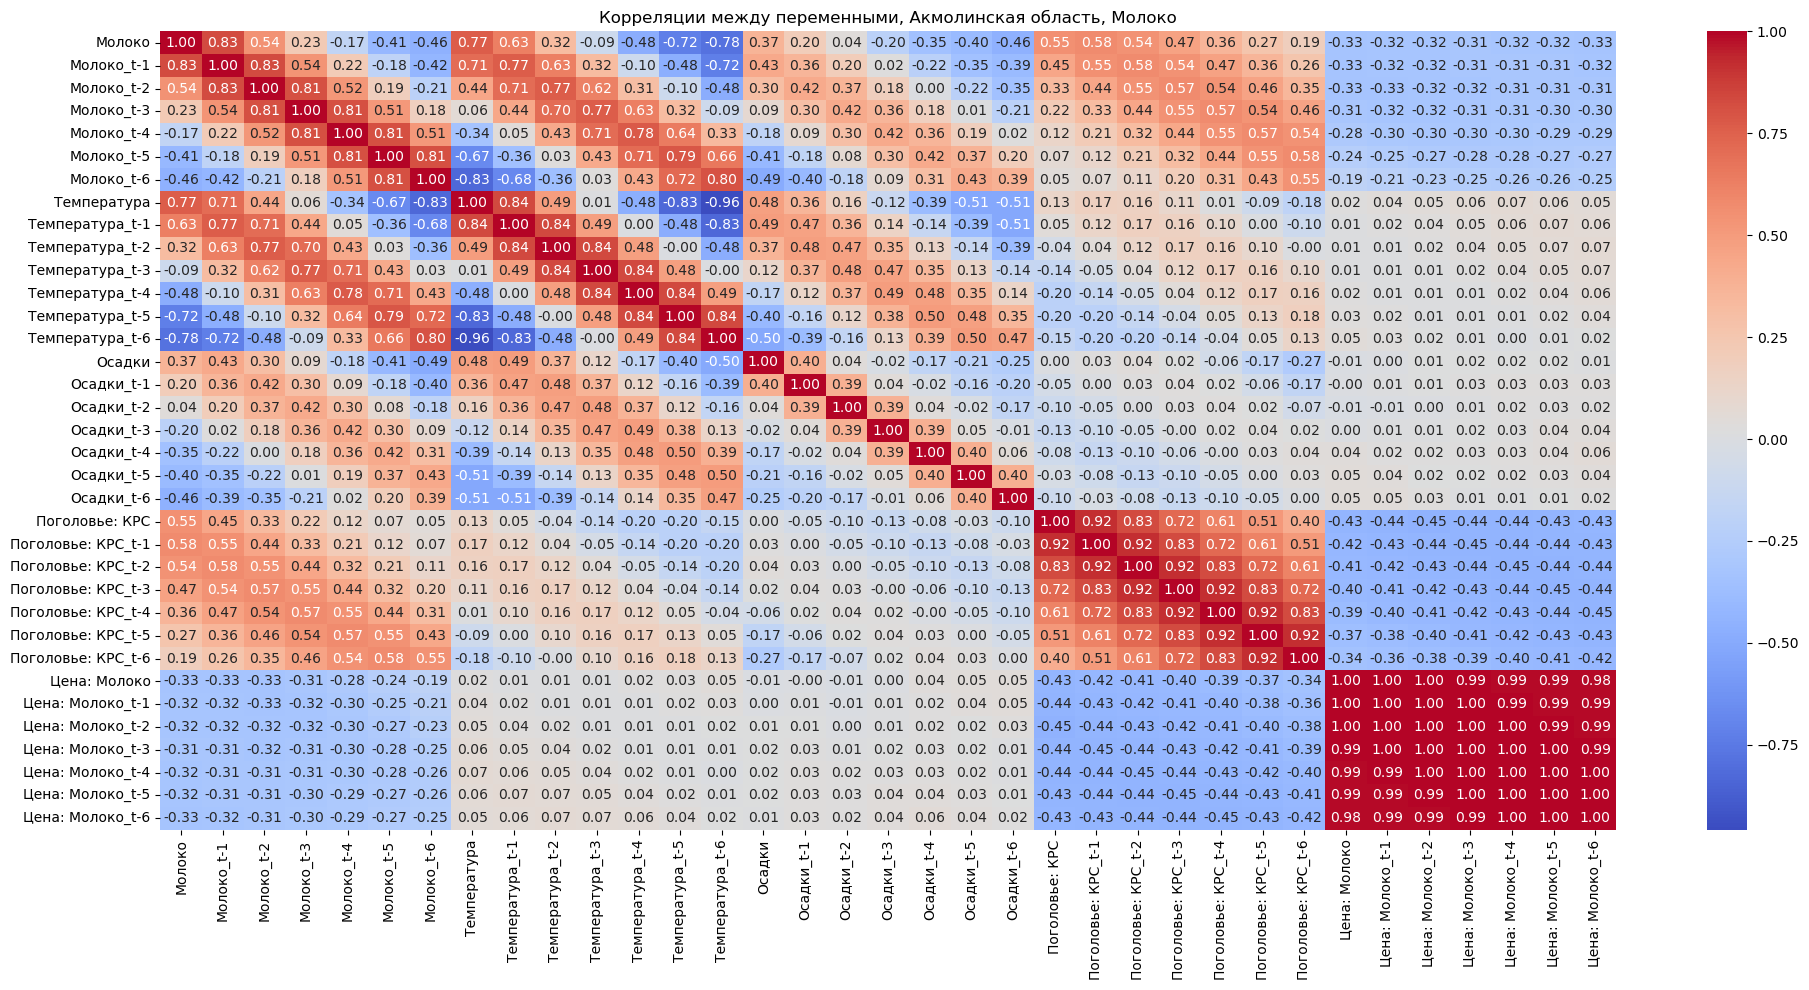

In [12]:
df_corr = df_akmola_full[[col for col in df_akmola_full.columns if col not in ["Период"]]].dropna().copy()

# 1. Correlation matrix
corr_matrix = df_corr.corr()

# 2. Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляции между переменными, Акмолинская область, Молоко")
plt.tight_layout()
plt.show()

*ВЫВОДЫ ПО КОРРЕЛЯЦИИ*

In [13]:
# Set your target variable
target_var = "Молоко"

# Get correlations with the target variable
target_corr = corr_matrix[target_var].drop(target_var)  # exclude self-correlation

# Keep only features with |correlation| >= 0.5
selected_vars = target_corr[abs(target_corr) >= 0.5].index.tolist()

print("✅ Отобранные переменные с корреляцией >= 0.5:")
print(selected_vars)

# Optionally: create new dataframe with selected variables + target
df_selected = df_akmola_full[['Период'] + selected_vars + [target_var]]
df_selected

✅ Отобранные переменные с корреляцией >= 0.5:
['Молоко_t-1', 'Молоко_t-2', 'Температура', 'Температура_t-1', 'Температура_t-5', 'Температура_t-6', 'Поголовье: КРС', 'Поголовье: КРС_t-1', 'Поголовье: КРС_t-2']


,Период,Молоко_t-1,Молоко_t-2,Температура,Температура_t-1,Температура_t-5,Температура_t-6,Поголовье: КРС,Поголовье: КРС_t-1,Поголовье: КРС_t-2,Молоко
0,2015-01-01,NaN,NaN,-12.490323,NaN,NaN,NaN,372560.0,NaN,NaN,12800.2
1,2015-02-01,12800.2,NaN,-10.192857,-12.490323,NaN,NaN,399442.0,372560.0,NaN,15349.3
2,2015-03-01,15349.3,12800.2,-5.870968,-10.192857,NaN,NaN,425605.0,399442.0,372560.0,25086.1
3,2015-04-01,25086.1,15349.3,4.490000,-5.870968,NaN,NaN,440023.0,425605.0,399442.0,31661.4
4,2015-05-01,31661.4,25086.1,14.574194,4.490000,NaN,NaN,444647.0,440023.0,425605.0,49129.8
...,...,...,...,...,...,...,...,...,...,...,...
115,2024-08-01,26267.7,28277.0,17.338710,20.270968,-4.809677,-13.644828,403674.0,408936.0,444063.0,22673.0
116,2024-09-01,22673.0,26267.7,11.300000,17.338710,8.026667,-4.809677,398450.0,403674.0,408936.0,22635.3
117,2024-10-01,22635.3,22673.0,3.832258,11.300000,10.696774,8.026667,392916.0,398450.0,403674.0,18373.4
118,2024-11-01,18373.4,22635.3,-4.343333,3.832258,21.043333,10.696774,387565.0,392916.0,398450.0,15949.9


In [14]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()

X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Молоко"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
2,Молоко_t-2,7.107311
7,Поголовье: КРС,7.279146
1,Молоко_t-1,8.077925
9,Поголовье: КРС_t-2,8.688155
5,Температура_t-5,10.757102
4,Температура_t-1,12.868678
8,Поголовье: КРС_t-1,15.781402
3,Температура,19.744642
6,Температура_t-6,19.835058
0,const,30.245340


In [15]:
df_selected = df_selected.drop(columns = ['Молоко_t-2', 'Температура_t-1', 'Температура_t-5', 'Температура_t-6', 'Поголовье: КРС', 'Поголовье: КРС_t-2'])
df_selected

,Период,Молоко_t-1,Температура,Поголовье: КРС_t-1,Молоко
0,2015-01-01,NaN,-12.490323,NaN,12800.2
1,2015-02-01,12800.2,-10.192857,372560.0,15349.3
2,2015-03-01,15349.3,-5.870968,399442.0,25086.1
3,2015-04-01,25086.1,4.490000,425605.0,31661.4
4,2015-05-01,31661.4,14.574194,440023.0,49129.8
...,...,...,...,...,...
115,2024-08-01,26267.7,17.338710,408936.0,22673.0
116,2024-09-01,22673.0,11.300000,403674.0,22635.3
117,2024-10-01,22635.3,3.832258,398450.0,18373.4
118,2024-11-01,18373.4,-4.343333,392916.0,15949.9


In [16]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()
X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Молоко"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
3,Поголовье: КРС_t-1,1.639993
2,Температура,2.354175
1,Молоко_t-1,3.246370
0,const,18.900116


In [17]:
df_selected = df_selected.dropna().copy()
df_selected

,Период,Молоко_t-1,Температура,Поголовье: КРС_t-1,Молоко
1,2015-02-01,12800.2,-10.192857,372560.0,15349.3
2,2015-03-01,15349.3,-5.870968,399442.0,25086.1
3,2015-04-01,25086.1,4.490000,425605.0,31661.4
4,2015-05-01,31661.4,14.574194,440023.0,49129.8
5,2015-06-01,49129.8,20.763333,444647.0,40606.1
...,...,...,...,...,...
115,2024-08-01,26267.7,17.338710,408936.0,22673.0
116,2024-09-01,22673.0,11.300000,403674.0,22635.3
117,2024-10-01,22635.3,3.832258,398450.0,18373.4
118,2024-11-01,18373.4,-4.343333,392916.0,15949.9


### Models

#### Многофакторная регрессия

In [18]:
# Define target and features
y = df_selected["Молоко"]
X = df_selected.drop(columns=["Период", "Молоко"])

# Add constant term
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Молоко   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     167.1
Date:                Tue, 19 Aug 2025   Prob (F-statistic):           9.37e-42
Time:                        15:52:25   Log-Likelihood:                -1179.2
No. Observations:                 119   AIC:                             2366.
Df Residuals:                     115   BIC:                             2377.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               4865.7982   1972

In [19]:
df_selected

,Период,Молоко_t-1,Температура,Поголовье: КРС_t-1,Молоко
1,2015-02-01,12800.2,-10.192857,372560.0,15349.3
2,2015-03-01,15349.3,-5.870968,399442.0,25086.1
3,2015-04-01,25086.1,4.490000,425605.0,31661.4
4,2015-05-01,31661.4,14.574194,440023.0,49129.8
5,2015-06-01,49129.8,20.763333,444647.0,40606.1
...,...,...,...,...,...
115,2024-08-01,26267.7,17.338710,408936.0,22673.0
116,2024-09-01,22673.0,11.300000,403674.0,22635.3
117,2024-10-01,22635.3,3.832258,398450.0,18373.4
118,2024-11-01,18373.4,-4.343333,392916.0,15949.9


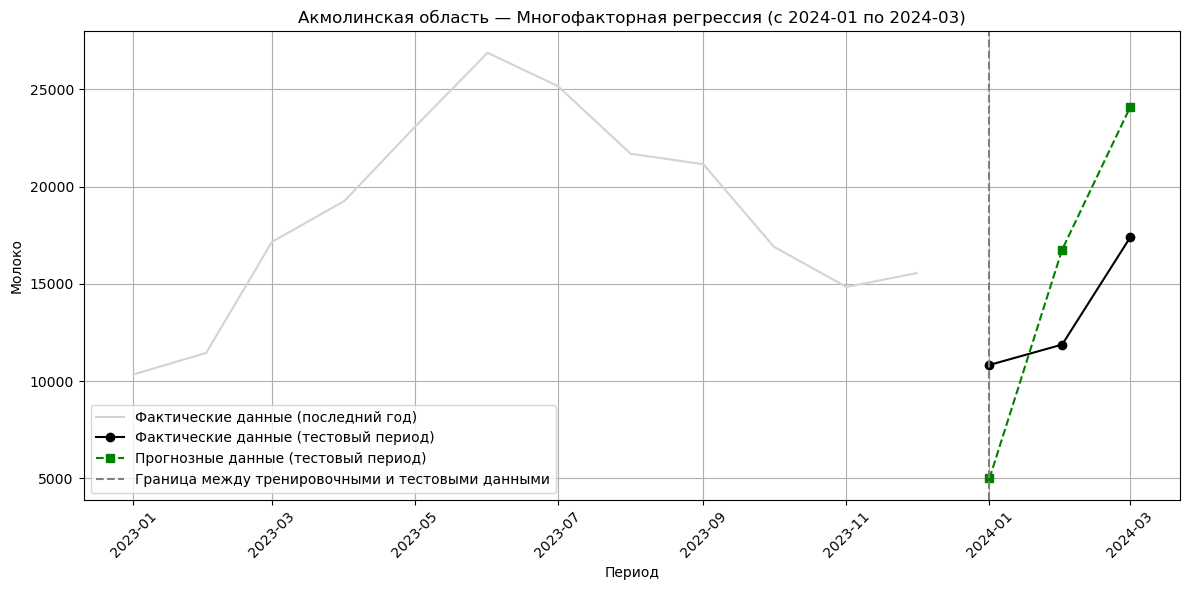

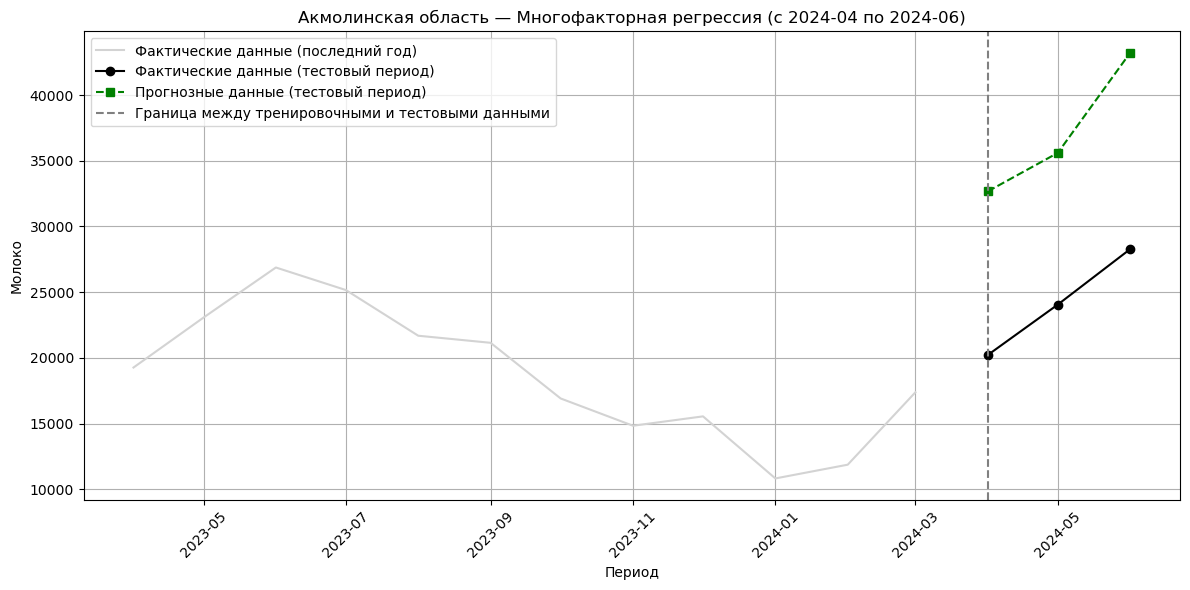

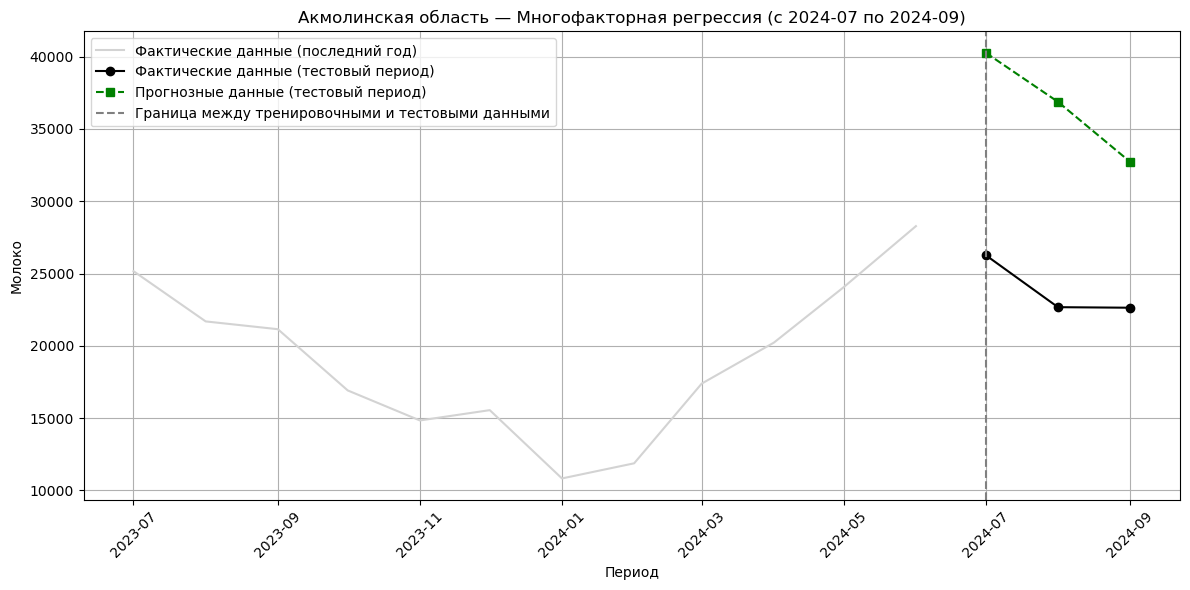

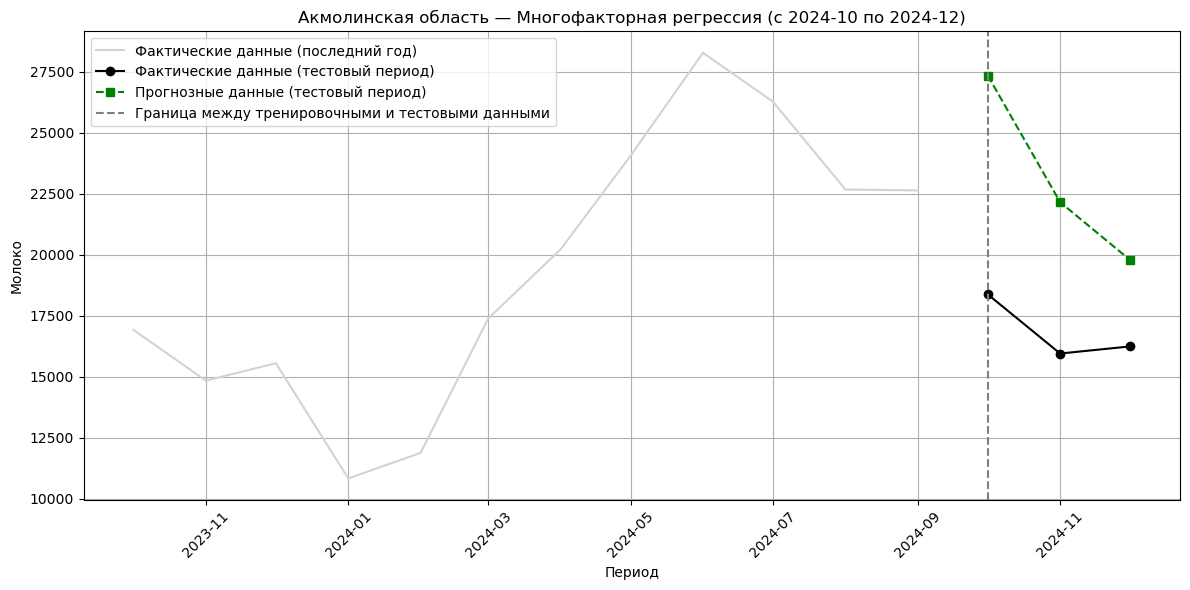

In [20]:
df = df_selected.sort_values("Период").copy()

target = "Молоко"
features = [col for col in df_selected.columns if col not in ['Период', 'Молоко']]

results = []

# Define 4 rolling test sets for 2024
start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

for start in start_dates:
    test_start = pd.to_datetime(start)
    test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Акмолинская область — Многофакторная регрессия (с {start} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Молоко")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period          RMSE           MAE   MAPE (%)
0  2024-01 to 2024-03   5851.627990   5804.431510  44.498717
1  2024-04 to 2024-06  13057.650000  12978.411626  54.130469
2  2024-07 to 2024-09  12900.065441  12760.211580  53.487788
3  2024-10 to 2024-12   6619.111641   6236.620221  36.495988
4             Average   9607.113768   9444.918734  47.153240


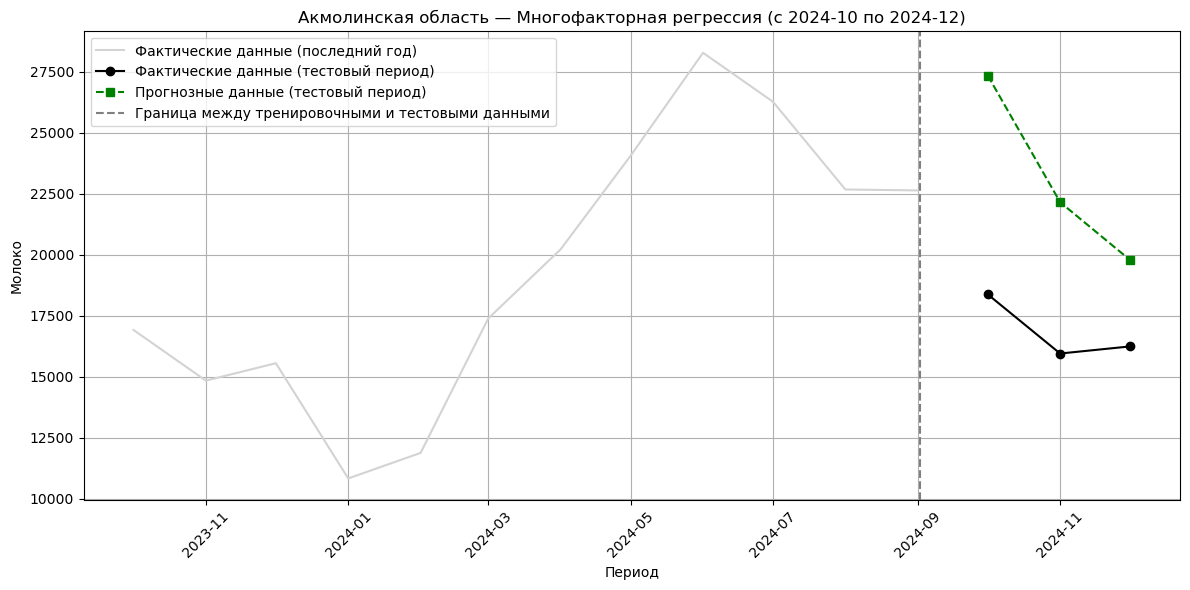

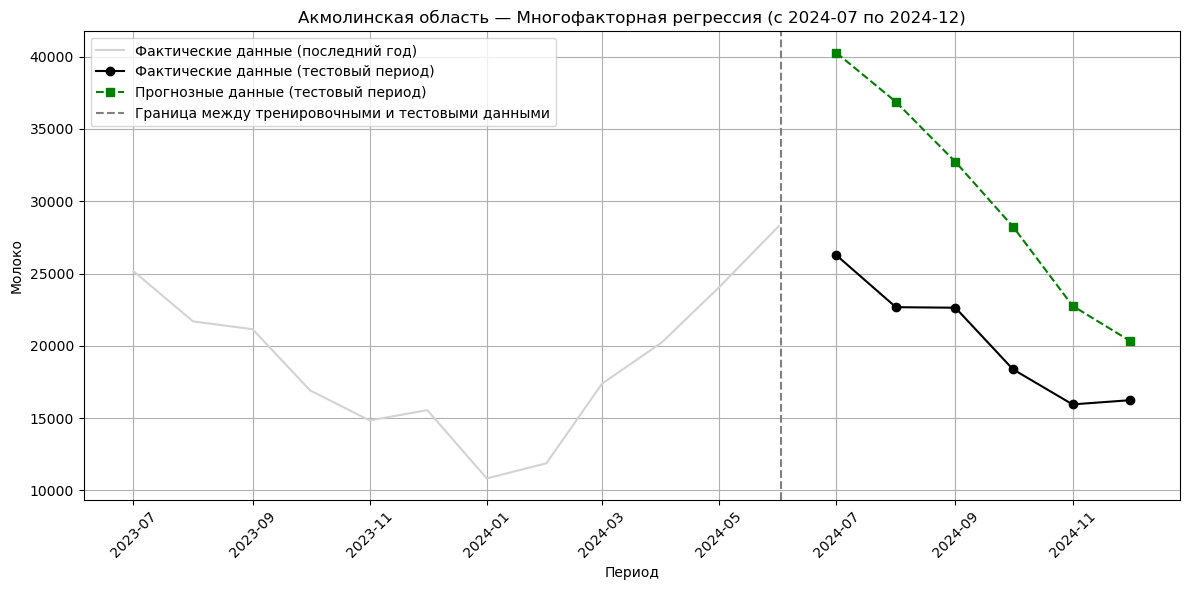

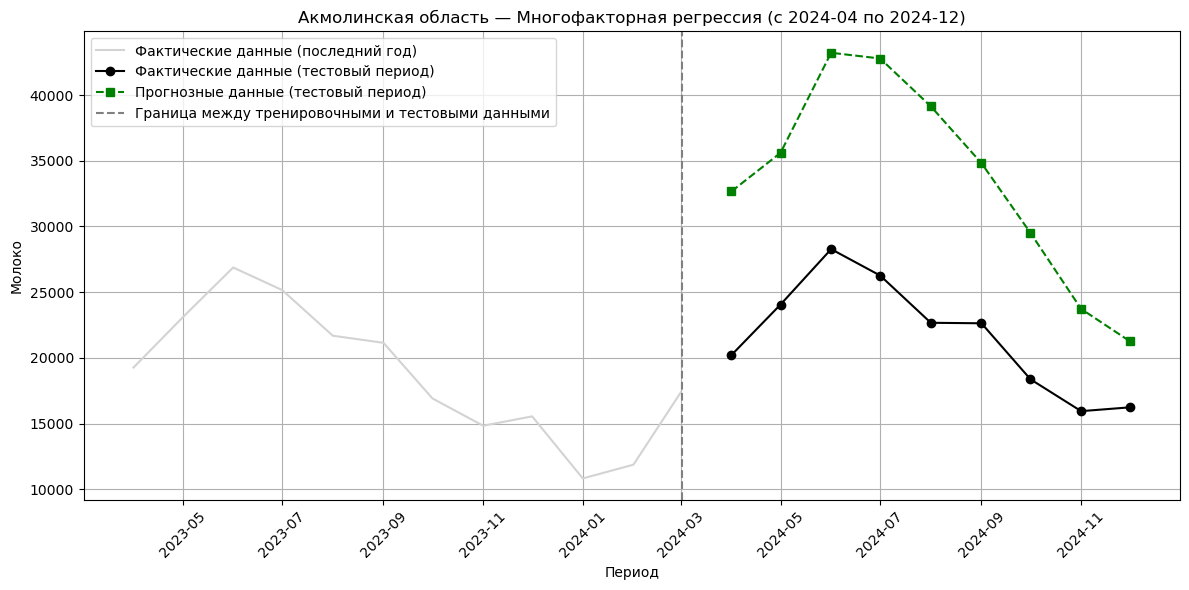

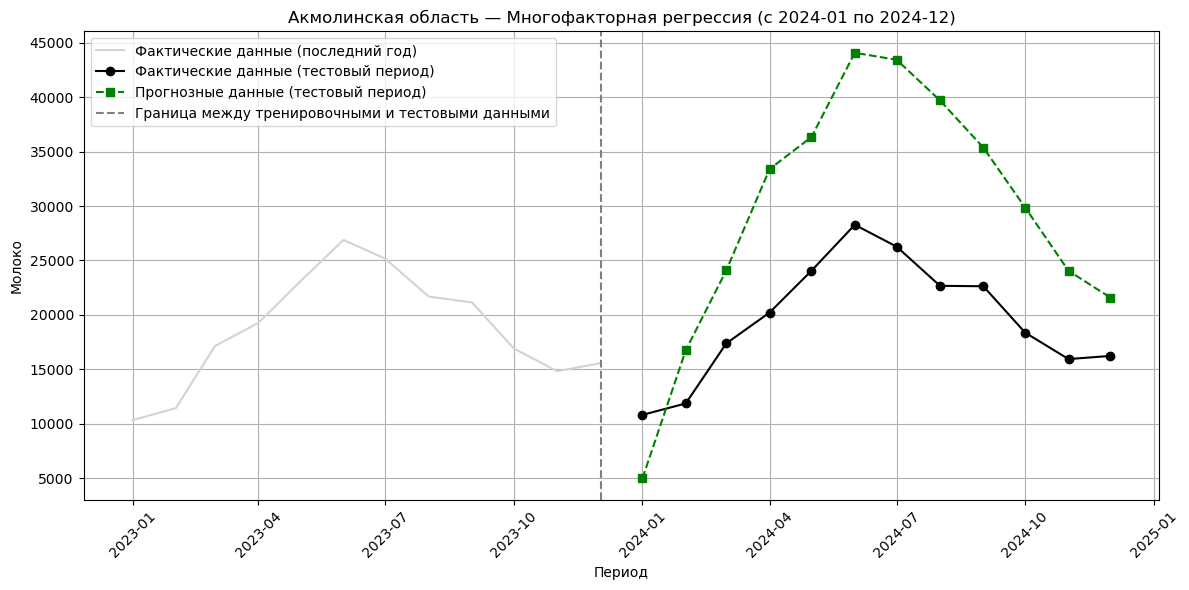

In [22]:
results = []

# Define 4 rolling test sets for 2024
horizons = [3, 6, 9, 12]

for horizon in horizons:

    test_end = pd.to_datetime("2024-12")
    test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Акмолинская область — Многофакторная регрессия (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Молоко")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period          RMSE           MAE   MAPE (%)
0  2024-10 to 2024-12   6619.111641   6236.620221  36.495988
1  2024-07 to 2024-12  10486.420735   9842.587659  47.015690
2  2024-04 to 2024-12  12531.612397  12002.359753  54.657776
3  2024-01 to 2024-12  11717.871734  10872.108500  54.019146
4             Average  10338.754126   9738.419033  48.047150


#### SARIMA (auto-arima)

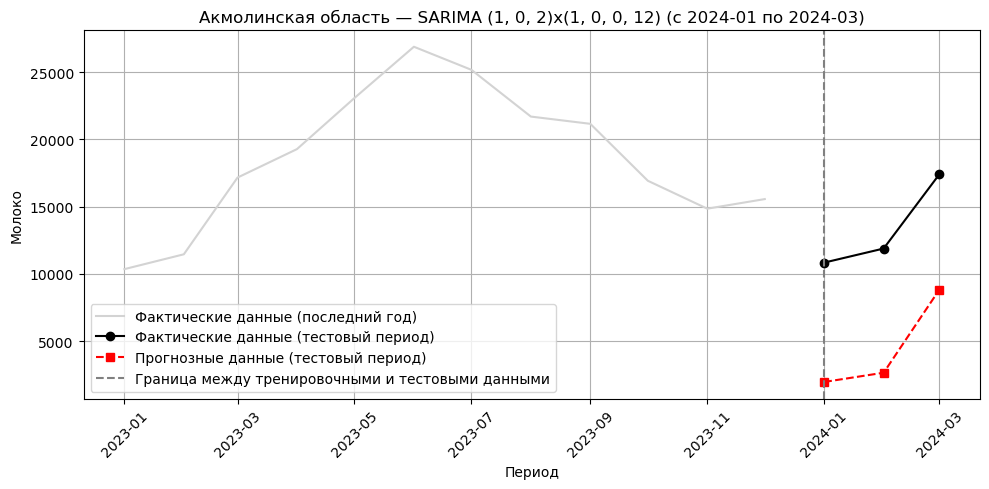

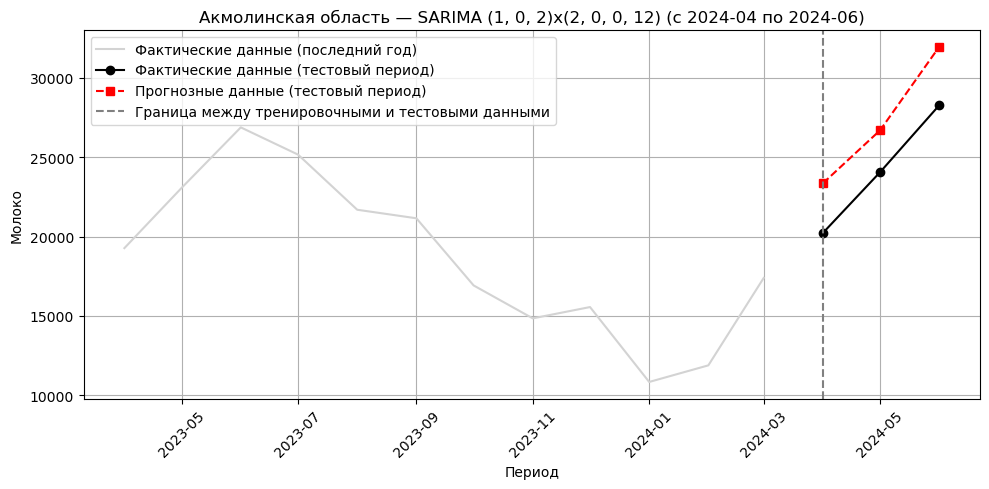

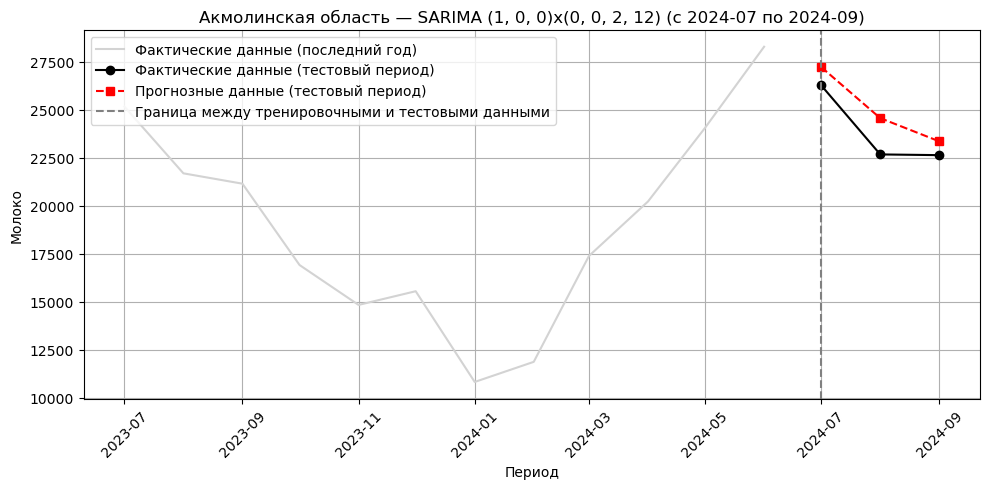

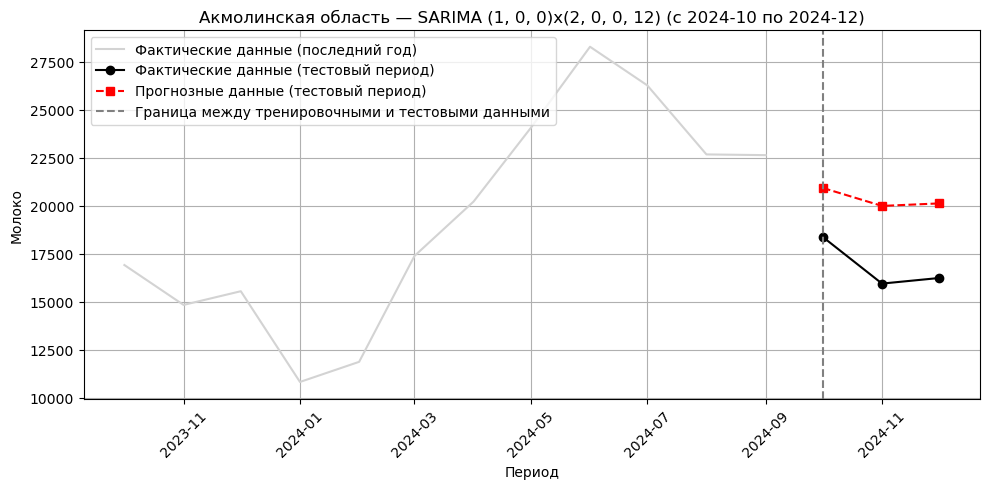

In [ ]:
# results = []

# # Определим 4 тестовых периода на 3 месяца
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Разделим данные
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=3)
#         forecast = pd.Series(forecast).reset_index(drop=True)


#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMA {model.order}x{model.seasonal_order} (с {test_start.strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()
#         # print("Zero values in y_test:", (y_test == 0).sum())


#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  8900.997576  8896.977329  69.686931    (1, 0, 2)   
1  2024-04 to 2024-06  3181.468886  3152.484551  13.164208    (1, 0, 2)   
2  2024-07 to 2024-09  1289.496905  1186.151826   5.041983    (1, 0, 0)   
3  2024-10 to 2024-12  3556.069022  3493.009764  21.050048    (1, 0, 0)   
4             Average  4232.008097  4182.155867  27.235792          NaN   

  Seasonal order  
0  (1, 0, 0, 12)  
1  (2, 0, 0, 12)  
2  (0, 0, 2, 12)  
3  (2, 0, 0, 12)  
4            NaN  


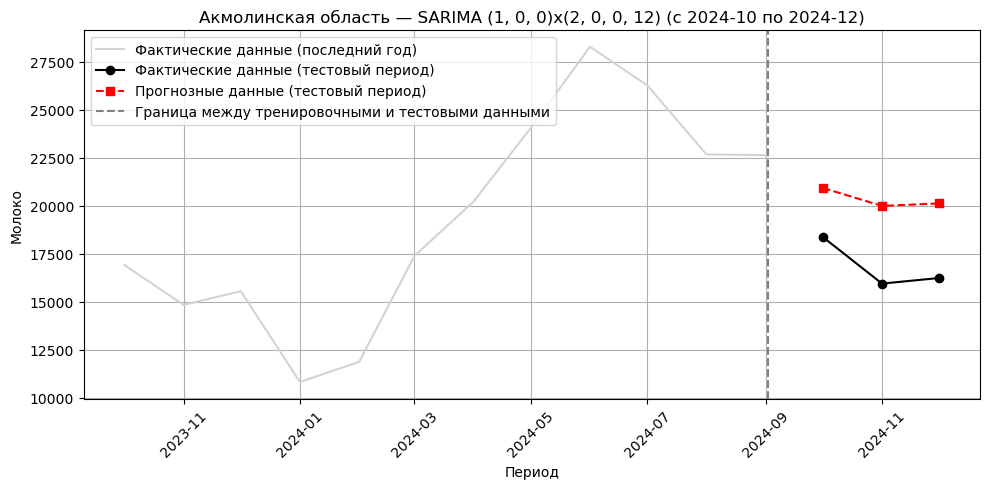

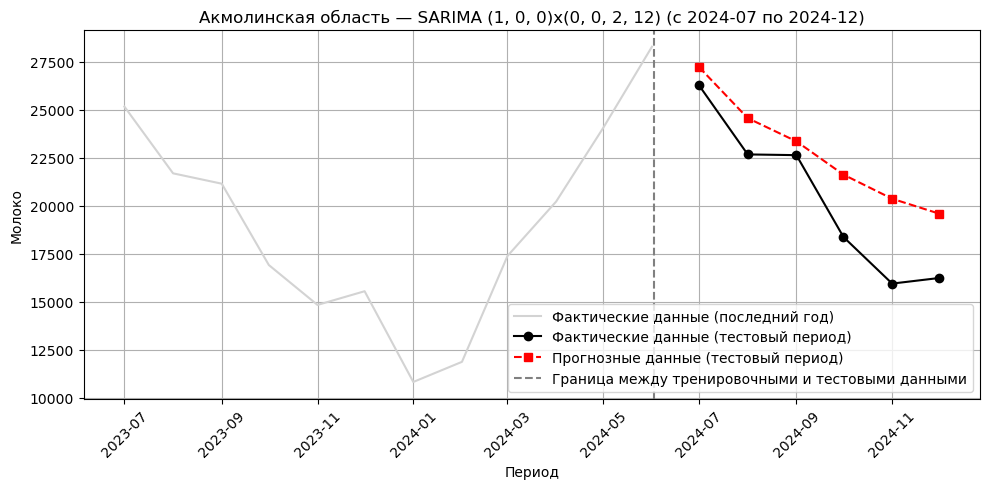

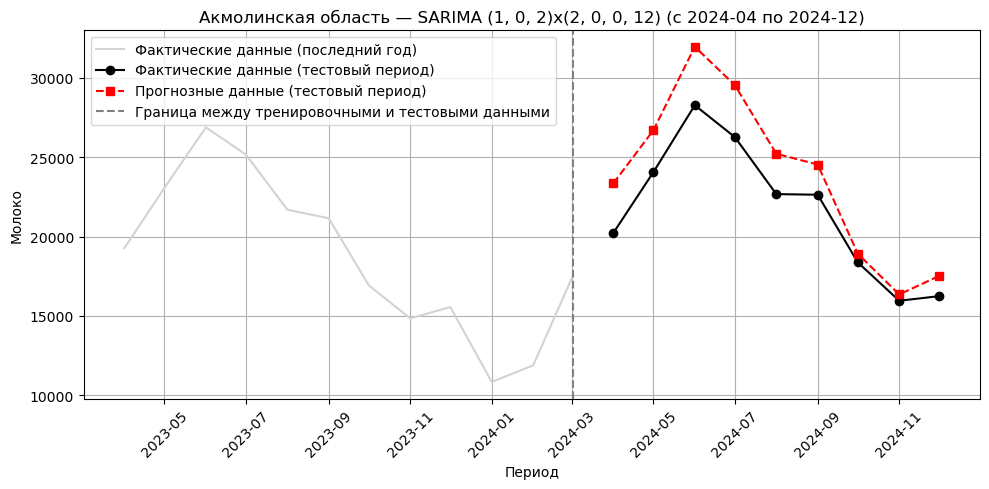

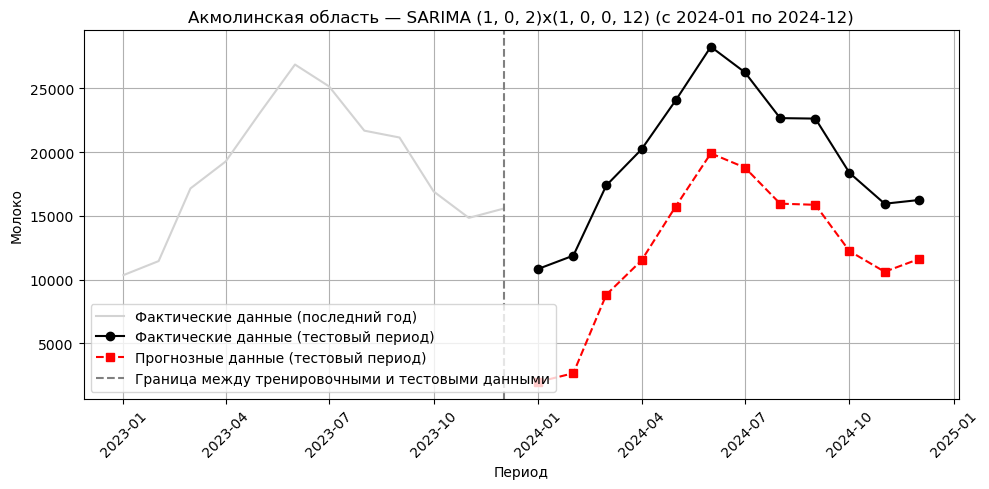

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:

#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)
    
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=horizon)
#         forecast = pd.Series(forecast).reset_index(drop=True)

#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMA {model.order}x{model.seasonal_order} (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12  3556.069022  3493.009764  21.050048    (1, 0, 0)   
1  2024-07 to 2024-12  2775.941324  2428.078554  13.515457    (1, 0, 0)   
2  2024-04 to 2024-12  2433.088844  2155.760058   9.435692    (1, 0, 2)   
3  2024-01 to 2024-12  7571.528574  7433.809779  41.660279    (1, 0, 2)   
4             Average  4084.156941  3877.664539  21.415369          NaN   

  Seasonal order  
0  (2, 0, 0, 12)  
1  (0, 0, 2, 12)  
2  (2, 0, 0, 12)  
3  (1, 0, 0, 12)  
4            NaN  


#### SARIMAX

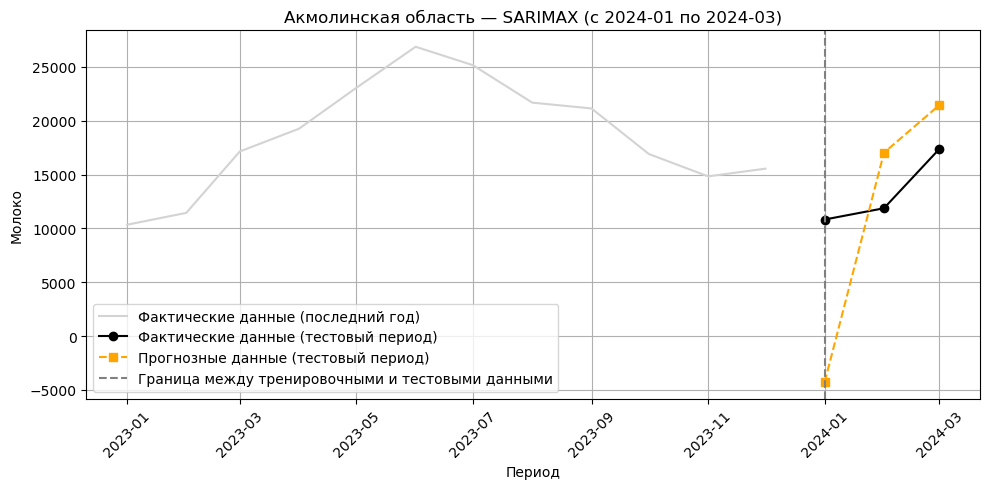

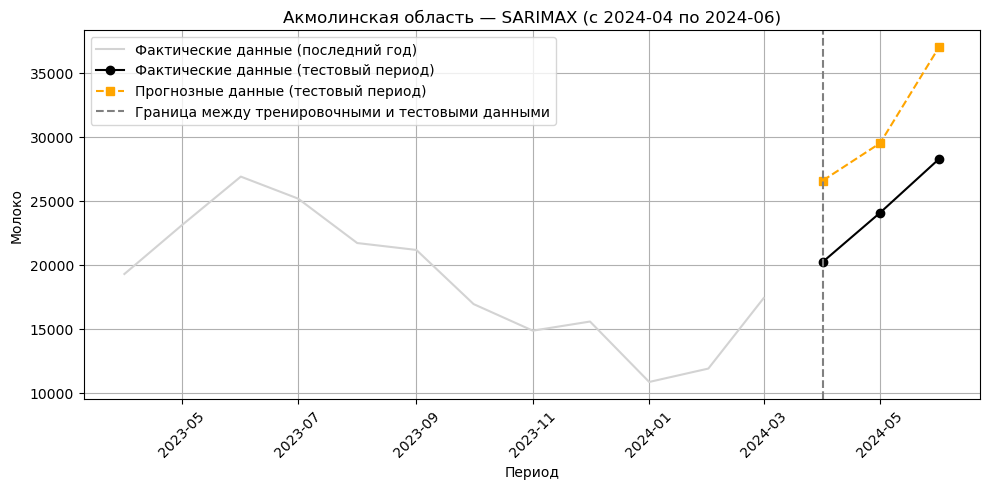

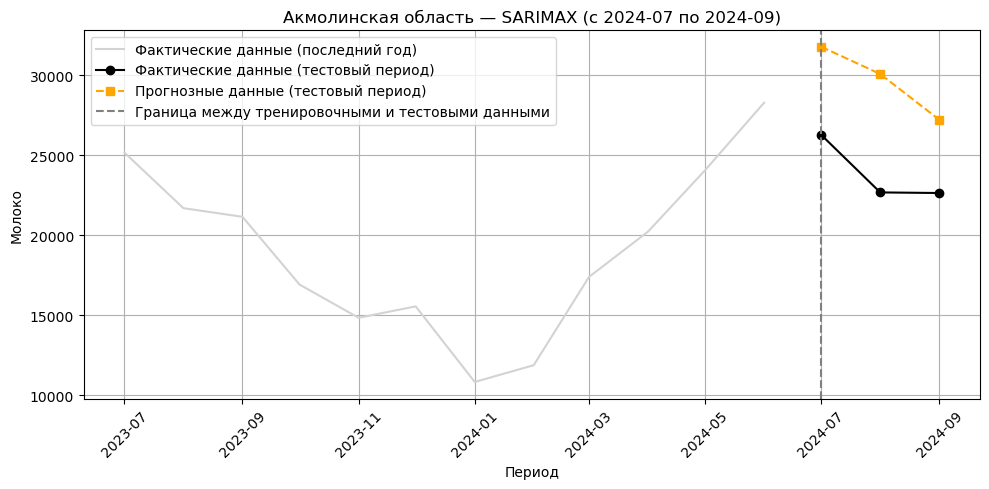

c:\Users\mjaks\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


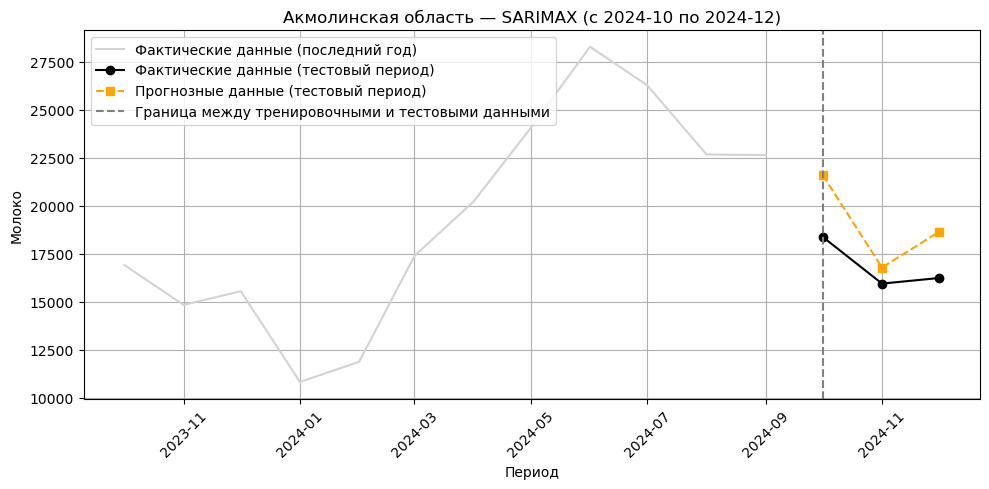

In [ ]:
# results = []

# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(1, 0, 0),
#             seasonal_order=(0, 0, 2, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=3, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMAX (с {start} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)



          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  9503.810282  8108.272019  68.739569            1   
1  2024-04 to 2024-06  6989.428705  6847.956060  28.324743            1   
2  2024-07 to 2024-09  5944.882552  5828.168738  24.608689            1   
3  2024-10 to 2024-12  2368.519974  2152.987108  12.522086            1   
4             Average  6201.660378  5734.345981  33.548772                

  Seasonal order  
0              0  
1              0  
2              0  
3              0  
4                 


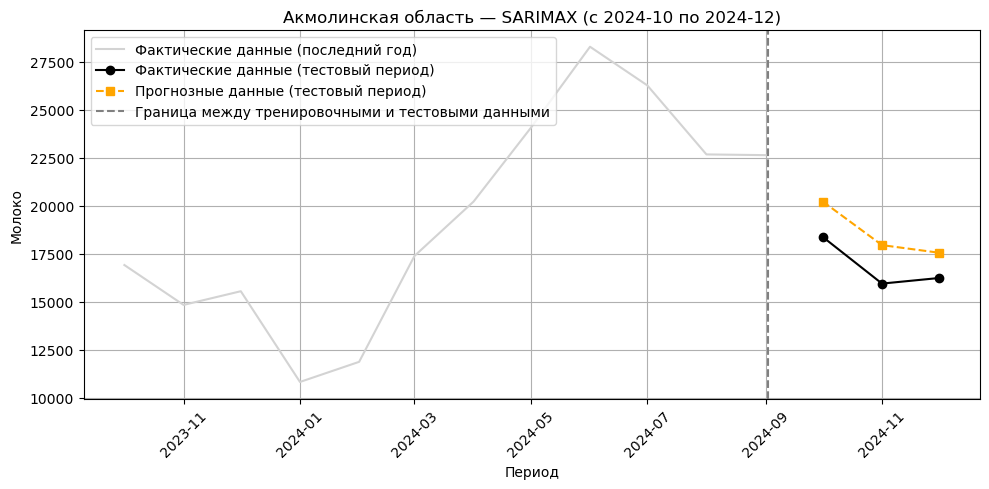

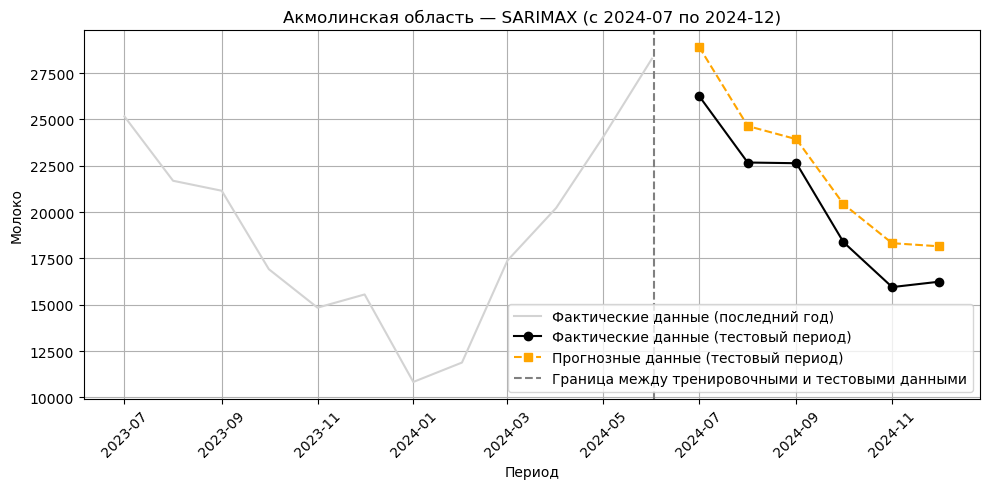

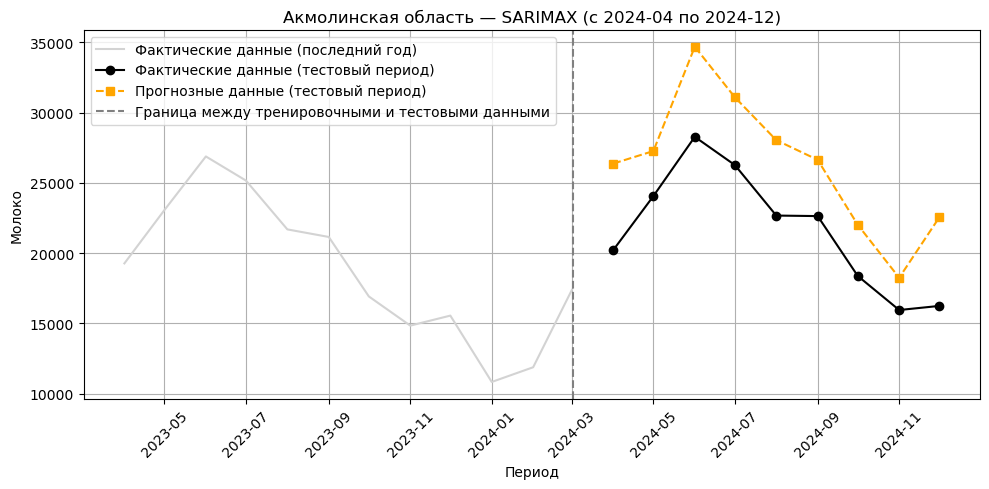

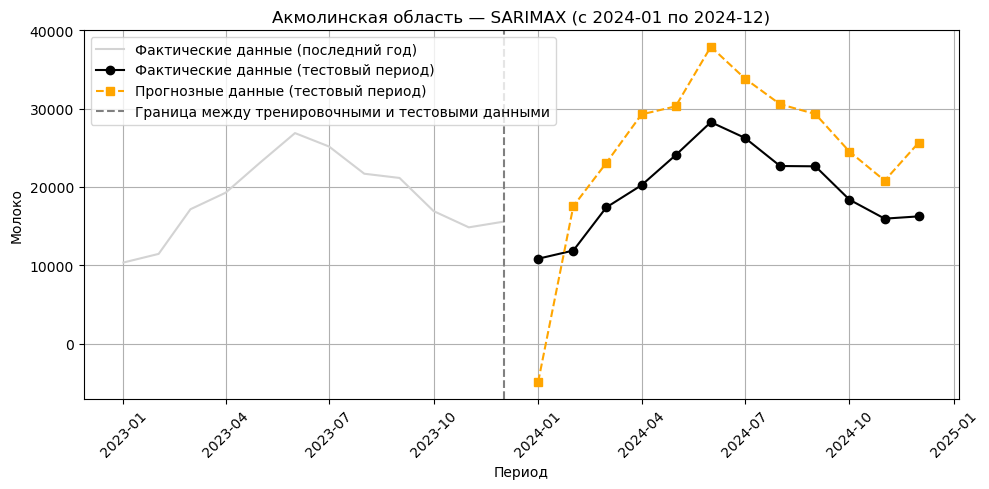

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:
#     # test_start = pd.to_datetime(start)
#     # test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(1, 0, 0),
#             seasonal_order=(1, 0, 0, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=horizon, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Акмолинская область — SARIMAX (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)

          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12  1745.863161  1720.809967  10.230512            1   
1  2024-07 to 2024-12  2085.103646  2042.278017  10.385788            1   
2  2024-04 to 2024-12  4893.575418  4688.624625  22.125986            1   
3  2024-01 to 2024-12  8368.155446  7882.056789  45.466247            1   
4             Average  4273.174418  4083.442349  22.052133                

  Seasonal order  
0             12  
1             12  
2             12  
3             12  
4                 


#### Prophet

15:24:37 - cmdstanpy - INFO - Chain [1] start processing
15:24:38 - cmdstanpy - INFO - Chain [1] done processing


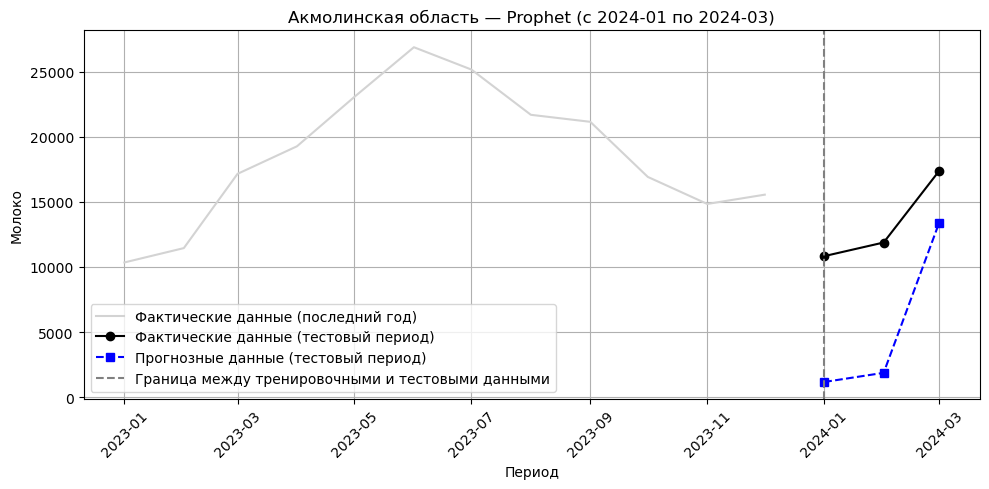

15:24:39 - cmdstanpy - INFO - Chain [1] start processing
15:24:39 - cmdstanpy - INFO - Chain [1] done processing


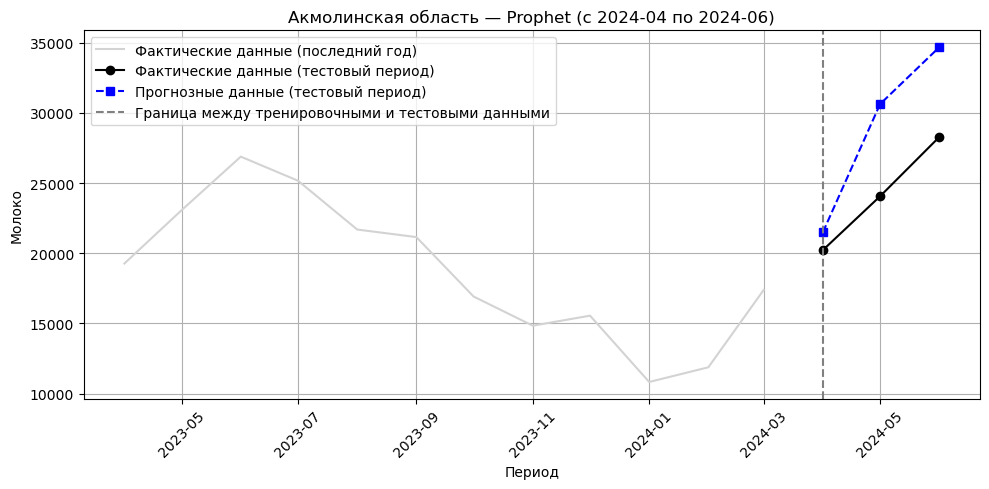

15:24:39 - cmdstanpy - INFO - Chain [1] start processing
15:24:39 - cmdstanpy - INFO - Chain [1] done processing


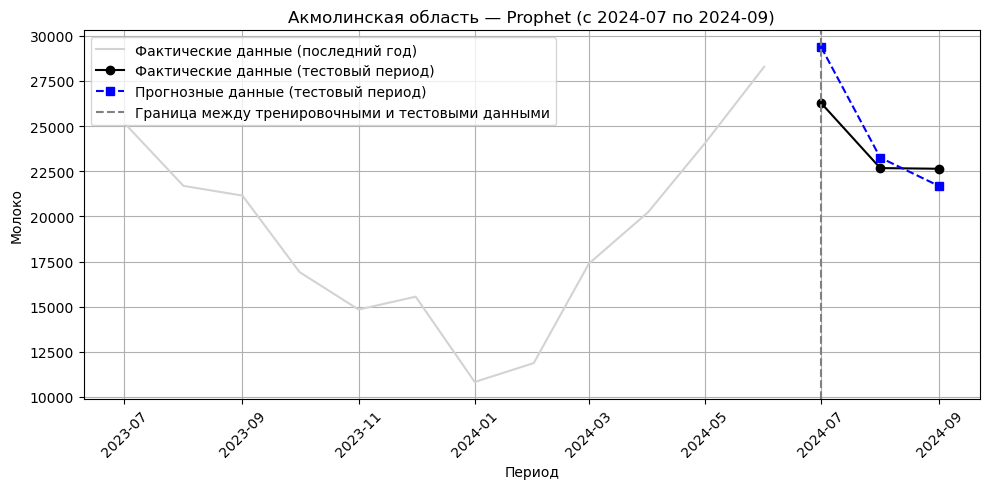

15:24:40 - cmdstanpy - INFO - Chain [1] start processing
15:24:40 - cmdstanpy - INFO - Chain [1] done processing


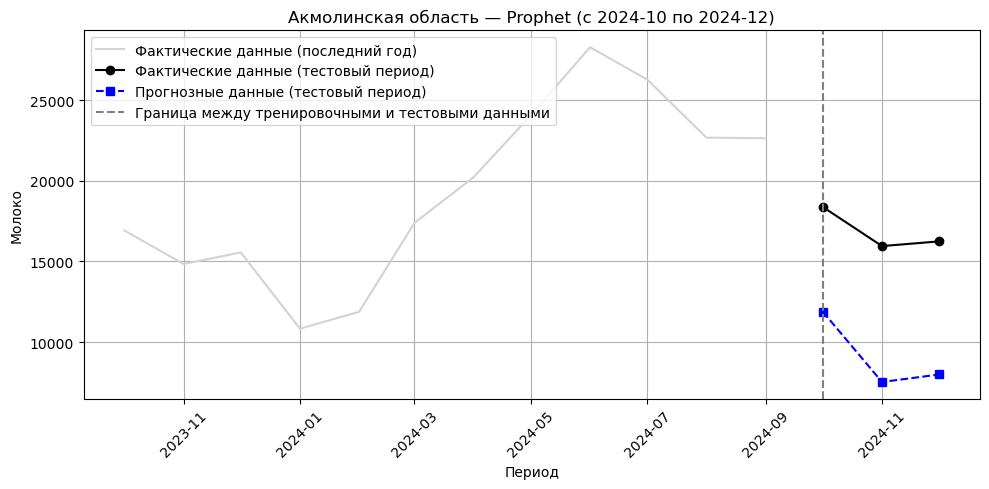

In [ ]:
# results = []

# # Define 4 test periods
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Train/test split
#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Initialize Prophet
#     model = Prophet()

#     # Optional: add regressors
#     # model.add_regressor("Температура_t-1")
#     # prophet_train["Температура_t-1"] = train_df["Температура_t-1"].values
#     # prophet_test["Температура_t-1"] = test_df["Температура_t-1"].values

#     # Fit
#     model.fit(prophet_train)

#     # Create future dataframe
#     future = model.make_future_dataframe(periods=3, freq="M")
#     forecast = model.predict(future)
# # forecast
# # prophet_test

#     # Extract forecast for test period only
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluate
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Акмолинская область — Prophet (с {start} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Молоко")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()



In [ ]:
# results_df = pd.DataFrame(results)
# avg = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg])], ignore_index=True)
# print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-01 to 2024-03  8357.266210  7885.283504  65.481103
1  2024-04 to 2024-06  5342.469439  4743.815059  18.729523
2  2024-07 to 2024-09  1901.571196  1545.385562   6.195341
3  2024-10 to 2024-12  7773.272512  7724.215411  46.327990
4             Average  5843.644839  5474.674884  34.183489


15:24:41 - cmdstanpy - INFO - Chain [1] start processing
15:24:41 - cmdstanpy - INFO - Chain [1] done processing


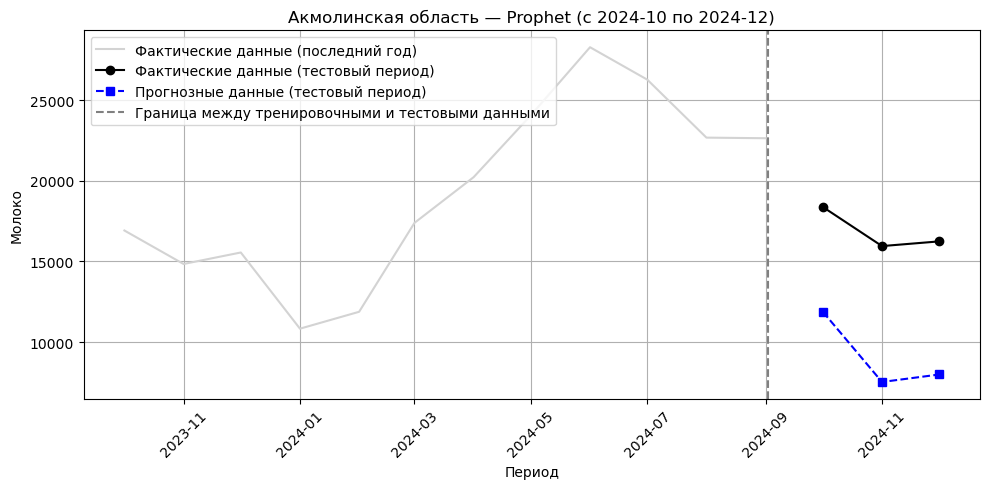

15:24:41 - cmdstanpy - INFO - Chain [1] start processing
15:24:41 - cmdstanpy - INFO - Chain [1] done processing


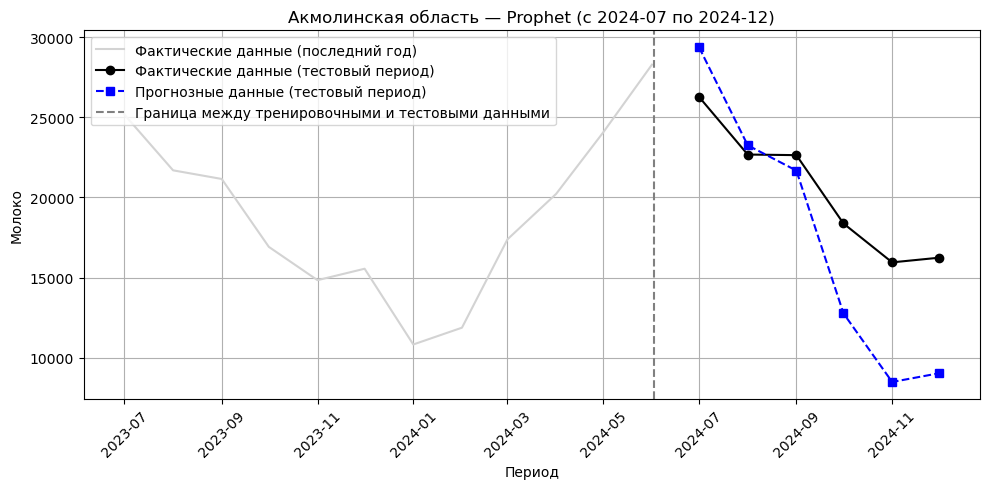

15:24:42 - cmdstanpy - INFO - Chain [1] start processing
15:24:42 - cmdstanpy - INFO - Chain [1] done processing


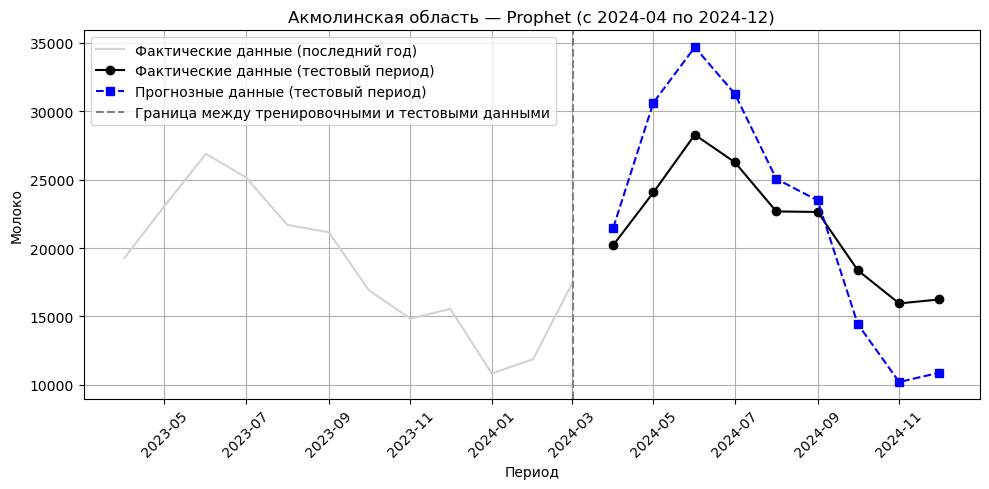

15:24:43 - cmdstanpy - INFO - Chain [1] start processing
15:24:43 - cmdstanpy - INFO - Chain [1] done processing


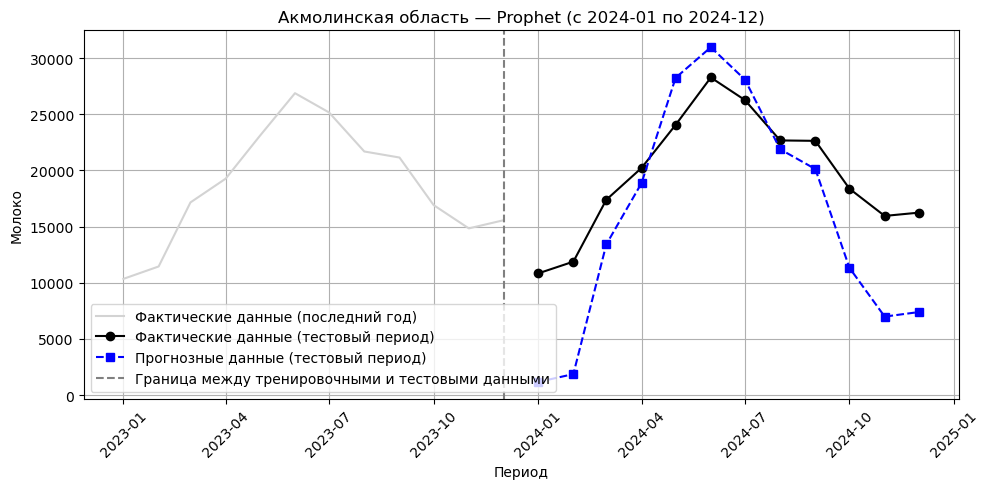

In [ ]:
# horizons = [3, 6, 9, 12]
# results = []

# for horizon in horizons:

#     # Define train/test split
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Fit Prophet
#     model = Prophet()
#     model.fit(prophet_train)

#     # Forecast
#     future = model.make_future_dataframe(periods=horizon, freq="M")
#     forecast = model.predict(future)

#     # Extract matching forecasted months
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluation
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Акмолинская область — Prophet (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Молоко")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()




In [ ]:
# # Summary table
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-10 to 2024-12  7773.272512  7724.215411  46.327990
1  2024-07 to 2024-12  4996.659340  4150.718997  23.368970
2  2024-04 to 2024-12  4644.160383  4164.856692  19.980216
3  2024-01 to 2024-12  6156.945254  5156.827610  33.389138
4                 NaN  5892.759372  5299.154677  30.766578


strength of correlation:
https://link.springer.com/article/10.1057/jt.2009.5#
https://resources.nu.edu/statsresources/correlation